# F1 Track Recognition — Training

> **Before starting:** Runtime → Change runtime type → **T4 GPU**

This notebook downloads the Roboflow dataset and trains a YOLOv8 classification model.

## 1 — Install

In [ ]:
!pip install ultralytics roboflow -q
import ultralytics; ultralytics.checks()

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


## 2 — Download dataset from Roboflow

Find your values at **roboflow.com → your project → Versions → Export → YOLOv8 → Show download code**

In [ ]:
from roboflow import Roboflow

API_KEY   = '<Your_API_KEY>' # roboflow.com → Settings → API
WORKSPACE = 'f1-yolo-project'
PROJECT   = 'f1_corner_detect'
VERSION   = 5

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download('folder')
print('✅ Dataset ready at:', dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to F1_corner_detect-5 in folder:: 100%|██████████| 8538/8538 [00:00<00:00, 8904.38it/s]

✅ Dataset ready at: /content/F1_corner_detect-5


In [ ]:
import os

train_path = os.path.join(dataset.location, 'train')
print('Training data:\n')
total = 0
for cls in sorted(os.listdir(train_path)):
    p = os.path.join(train_path, cls)
    if os.path.isdir(p):
        n = len(os.listdir(p))
        total += n
        bar = '█' * (n // 10)
        print(f'  {cls:<35s} {n:>4}  {bar}')
print(f'\n  TOTAL: {total} images')

📊 Training data:

  Corners Spa                           15  █
  Corners Spa Spa_Kemmel_Straight Spa_turn5 Spa_turn6 Straights   22  ██
  Corners Spa Spa_Kemmel_Straight Spa_turn5 Straights   58  █████
  Corners Spa Spa_turn1                542  ██████████████████████████████████████████████████████
  Corners Spa Spa_turn10                40  ████
  Corners Spa Spa_turn11                48  ████
  Corners Spa Spa_turn12                52  █████
  Corners Spa Spa_turn13               103  ██████████
  Corners Spa Spa_turn14                35  ███
  Corners Spa Spa_turn15                56  █████
  Corners Spa Spa_turn16               112  ███████████
  Corners Spa Spa_turn17                68  ██████
  Corners Spa Spa_turn18               133  █████████████
  Corners Spa Spa_turn18 Spa_turn19    134  █████████████
  Corners Spa Spa_turn19               251  █████████████████████████
  Corners Spa Spa_turn2                 39  ███
  Corners Spa Spa_turn2 Spa_turn3      122  ████████████

## 3 — Train

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

results = model.train(
    data=dataset.location,
    epochs=20,
    imgsz=224,
    batch=32,
    patience=20,          # No progress = early stop
    pretrained=True,      # Transfer Learning
    optimizer='Adam',
    lr0=0.001,
    name='f1_model',
    plots=True,
)
print('\nTraining complete!')

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/F1_corner_detect-5, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=f1_model-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patie

## 4 — Results

Run: runs/classify/f1_model-3



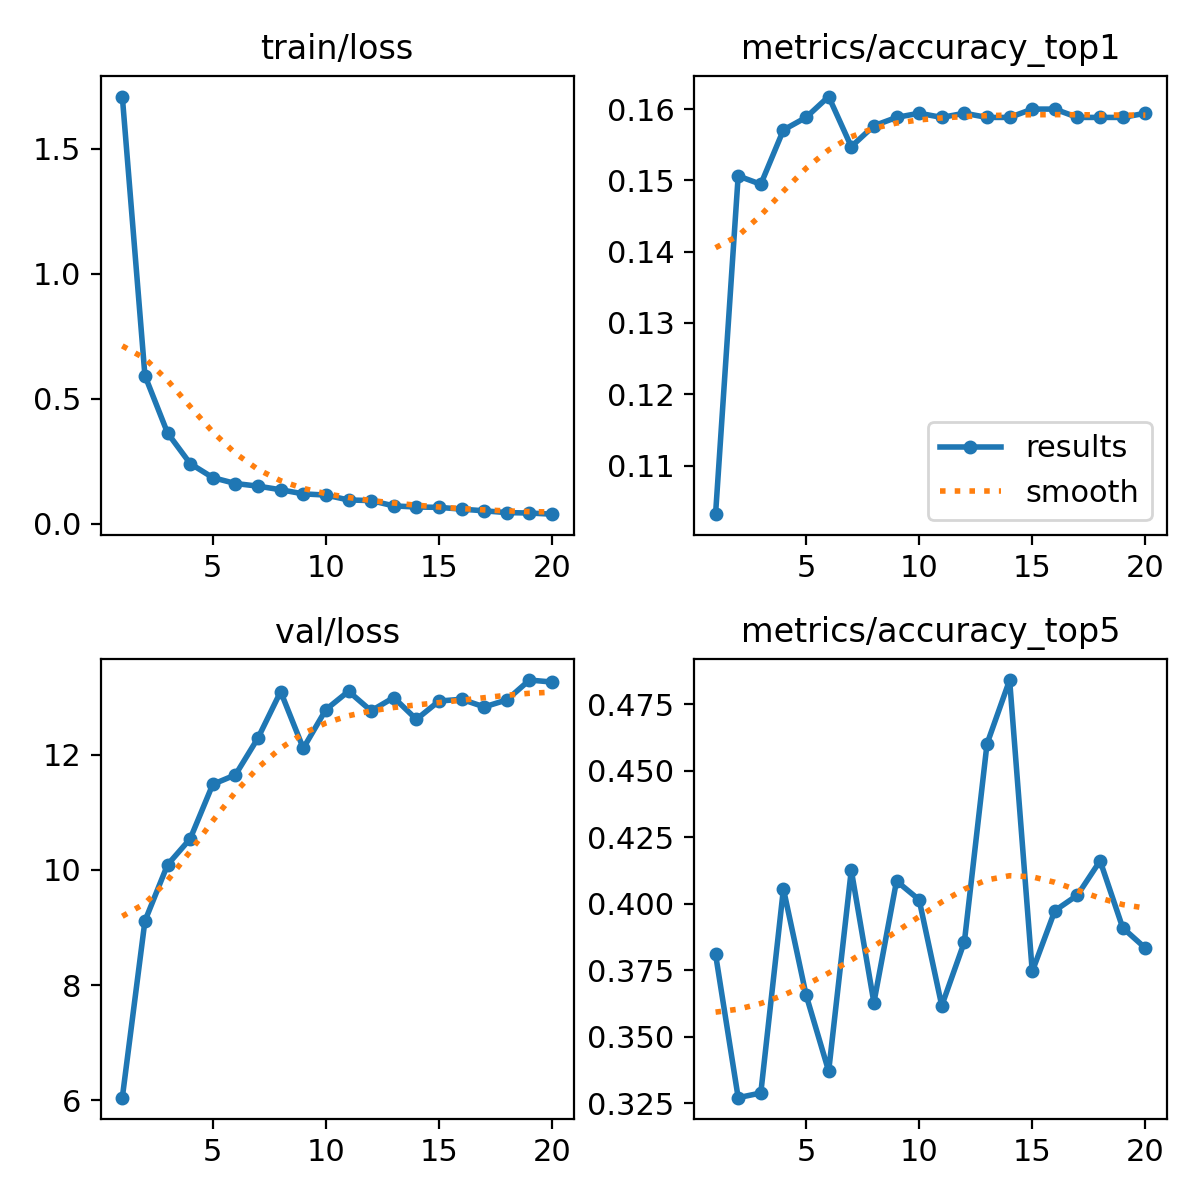

In [ ]:
from IPython.display import Image, display
import glob

run_dir = sorted(glob.glob('runs/classify/f1_model*'))[-1]
print(f'Run: {run_dir}\n')
display(Image(os.path.join(run_dir, 'results.png')))

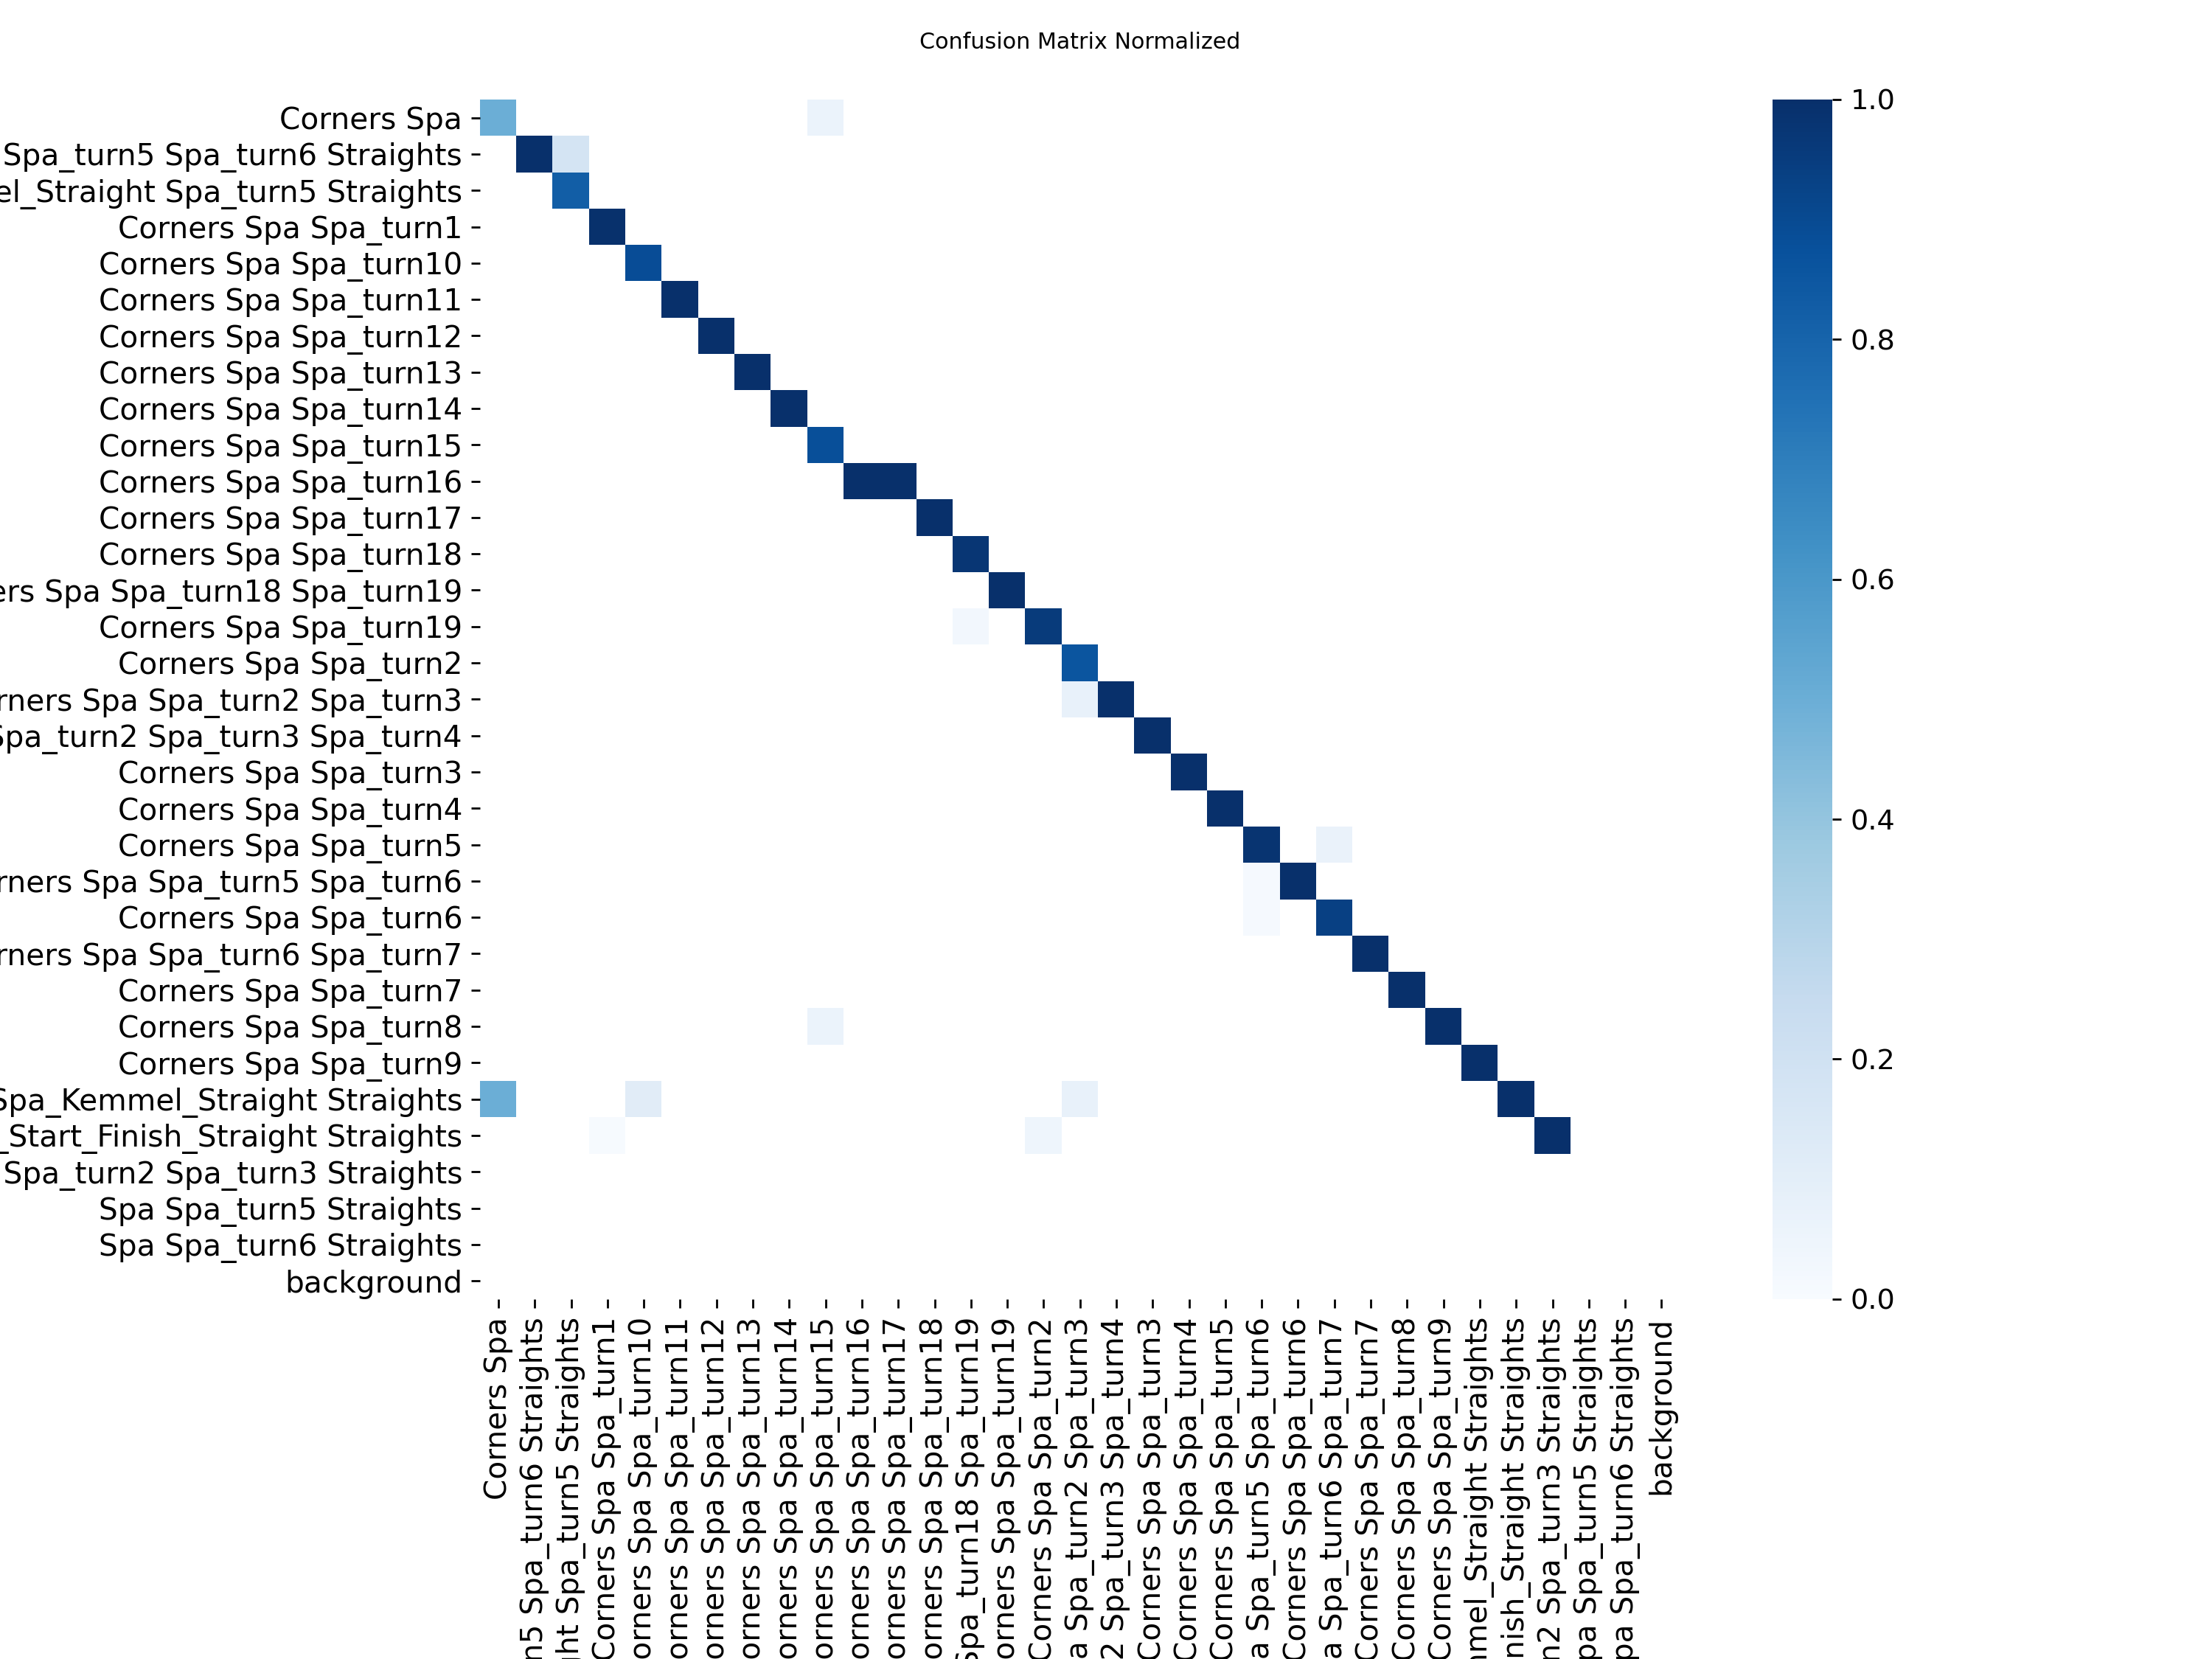

In [ ]:
# Confusion Matrix — sieht gut aus in der Präsentation!
cm_path = os.path.join(run_dir, 'confusion_matrix_normalized.png')
if os.path.exists(cm_path):
    display(Image(cm_path))

In [ ]:
# Accuracy auf Test-Set
best = YOLO(os.path.join(run_dir, 'weights', 'best.pt'))
val  = best.val(data=dataset.location, split='test')
print(f'\n Top-1 Accuracy: {val.top1:.1%}')
print(f'   Top-5 Accuracy: {val.top5:.1%}')

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,475,872 parameters, 0 gradients, 3.3 GFLOPs
train: /content/F1_corner_detect-5/train... found 5977 images in 32 classes ✅ 
ERROR ❌ val: /content/F1_corner_detect-5/valid... found 1706 images in 30 classes (requires 32 classes, not 30)
ERROR ❌ test: /content/F1_corner_detect-5/test... found 853 images in 28 classes (requires 32 classes, not 28)
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 242.0±57.9 MB/s, size: 10.3 KB)
test: Scanning /content/F1_corner_detect-5/test... 853 images, 0 corrupt: 100% ━━━━━━━━━━━━ 853/853 4.7Kit/s 0.2s
test: New cache created: /content/F1_corner_detect-5/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 54/54 25.3it/s 2.1s
                   all      0.286      0.445
Speed: 0.2ms preprocess, 1.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-3

🎯 Top-1 Ac

## 5 — Download model

In [ ]:
import shutil
from google.colab import files

shutil.copy(os.path.join(run_dir, 'weights', 'best.pt'), 'f1_model_best.pt')
files.download('f1_model_best.pt')
print(' Model saved!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model saved!
